In [103]:
## import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [104]:
#loading the dataset
df = pd.read_csv('japan_immigration_statistics_inbound.csv')

## Dataset overview

In [105]:
df.head(3)


,year,total,asia,afghanistan,united_arab_emirates,myanmar,bahrain,bhutan,bangladesh,brunei,...,nauru,papua_new_guinea,palau,solomon_islands,tonga,tuvalu,vanuatu,samoa,stateless,unknown_other
0,1950,18046,4135,NaN,NaN,36,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125,2.0
1,1951,24268,7049,1.0,NaN,25,NaN,NaN,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,171,1.0
2,1952,32262,8503,2.0,NaN,88,2.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,3.0


In [106]:
df.tail(3)

,year,total,asia,afghanistan,united_arab_emirates,myanmar,bahrain,bhutan,bangladesh,brunei,...,nauru,papua_new_guinea,palau,solomon_islands,tonga,tuvalu,vanuatu,samoa,stateless,unknown_other
53,2003,5727240,3793793,598.0,462.0,3509,153.0,223.0,7229.0,653.0,...,29.0,427.0,346.0,124.0,365.0,39.0,63.0,172.0,1424,NaN
54,2004,6756830,4607027,1029.0,816.0,3945,344.0,263.0,8501.0,655.0,...,21.0,384.0,388.0,98.0,305.0,42.0,65.0,200.0,1111,NaN
55,2005,7450103,5134673,2142.0,641.0,4333,417.0,339.0,8377.0,762.0,...,25.0,521.0,504.0,186.0,292.0,57.0,78.0,204.0,1182,NaN


In [107]:
#To get the dimension: number of rows and columns

df.shape

(56, 207)

In [108]:
#To get the column names
df.columns

Index(['year', 'total', 'asia', 'afghanistan', 'united_arab_emirates',
       'myanmar', 'bahrain', 'bhutan', 'bangladesh', 'brunei',
       ...
       'nauru', 'papua_new_guinea', 'palau', 'solomon_islands', 'tonga',
       'tuvalu', 'vanuatu', 'samoa', 'stateless', 'unknown_other'],
      dtype='object', length=207)

In [109]:
# To see what are the datatypes in the columns used in each
df.dtypes

,0
year,int64
total,int64
asia,int64
afghanistan,float64
united_arab_emirates,float64
...,...
tuvalu,float64
vanuatu,float64
samoa,float64
stateless,int64


In [110]:
# To check the null values the columns and count them
df.isnull().sum()

,0
year,0
total,0
asia,0
afghanistan,1
united_arab_emirates,22
...,...
tuvalu,30
vanuatu,31
samoa,13
stateless,0


In [111]:
# Calculate the number of null values per column
null_counts = df.isnull().sum()

# Count how many columns have at least one null value
columns_with_nulls = null_counts[null_counts > 0]

print(f"Number of columns with null values: {len(columns_with_nulls)}")
print("Columns with null values and their respective counts:")
display(columns_with_nulls)

Number of columns with null values: 148
Columns with null values and their respective counts:


,0
afghanistan,1
united_arab_emirates,22
bahrain,4
bhutan,11
bangladesh,22
...,...
tonga,21
tuvalu,30
vanuatu,31
samoa,13


In [112]:
# to check if there is any duplicates
df.duplicated().any()

np.False_

# **Exploratory Analysis**

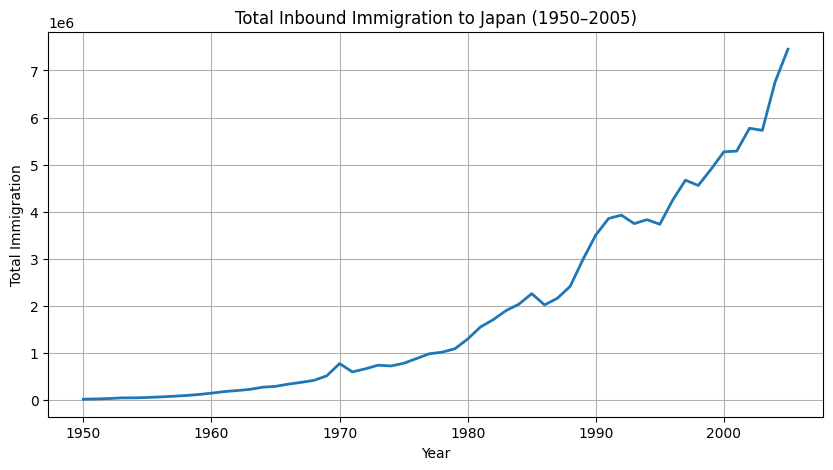

In [113]:
# total immigration over time to show non-statinarity


df = df.sort_values('year')


plt.figure(figsize=(10, 5))

plt.plot(df['year'], df['total'], linewidth=2)

plt.xlabel('Year')

plt.ylabel('Total Immigration')

plt.title('Total Inbound Immigration to Japan (1950–2005)')

plt.grid(True)

plt.show()

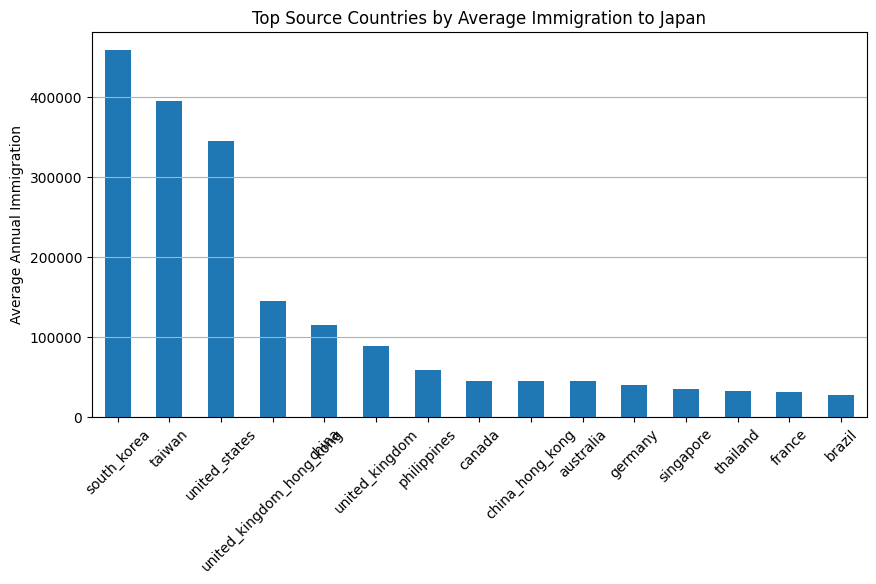

In [114]:
# Compute average immigration per country

avg_immigration = df.drop(columns=["total"], errors="ignore").mean()

#drop continent asia, south-america, oceania, asia form the avg immigration
avg_immigration = avg_immigration.drop(['asia', 'south_america', 'oceania', 'asia','europe','north_america'])

# Select top contributors

top_countries = avg_immigration.sort_values(ascending=False).head(15)



plt.figure(figsize=(10, 5))

top_countries.plot(kind="bar")

plt.ylabel("Average Annual Immigration")

plt.title("Top Source Countries by Average Immigration to Japan")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

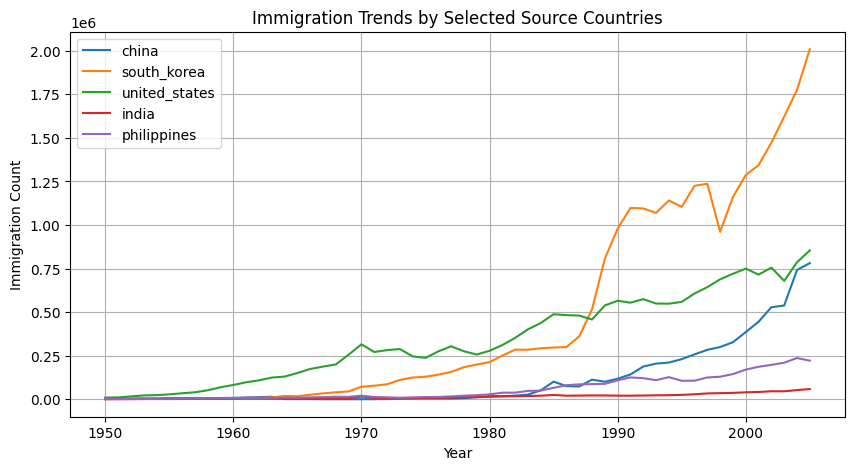

In [115]:
## heteregeneity accross country for china, south korea, united states, india and phillipines

selected_countries = ['china', 'south_korea', 'united_states', 'india', 'philippines']

plt.figure(figsize=(10, 5))


for country in selected_countries:
    plt.plot(df['year'], df[country], label=country)


plt.xlabel('Year')

plt.ylabel('Immigration Count')

plt.title('Immigration Trends by Selected Source Countries')

plt.legend()

plt.grid(True)

plt.show()

# **Pre-processing**

In [116]:
#Standardize column names to replace spacing with "_"

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Rename key columns for clarity

df = df.rename(columns={
    "year": "year",
    "total": "total",
    "odname": "country",
    "areaname": "areaname",
    "regname": "regname"
})

#converting the whole year column to numberic
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Convert all non-year columns to numeric
for col in df.columns:
    if col != "year":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Conversion to time-series
df = df.sort_values("year")
df.set_index("year", inplace=True)


# replacing Null values by "o"
df=df.fillna(0)
# Display

print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 1950 to 2005
Columns: 206 entries, total to unknown_other
dtypes: float64(148), int64(58)
memory usage: 90.6 KB
None
      total   asia  afghanistan  united_arab_emirates  myanmar  bahrain  \
year                                                                      
1950  18046   4135          0.0                   0.0       36      0.0   
1951  24268   7049          1.0                   0.0       25      0.0   
1952  32262   8503          2.0                   0.0       88      2.0   
1953  46857  13343          4.0                   0.0      103      0.0   
1954  47425  13317          5.0                   0.0      158      3.0   

      bhutan  bangladesh  brunei  cambodia  ...  nauru  papua_new_guinea  \
year                                        ...                            
1950     1.0         0.0     0.0       0.0  ...    0.0               0.0   
1951     0.0         0.0     0.0       8.0  ...    0.0               0.0

# **Log1p standardizing and Modelling**

The model summary provides statistical insights into the model's performance. Now, let's visualize the residuals and the observed vs. fitted values to check for model assumptions and fit quality.

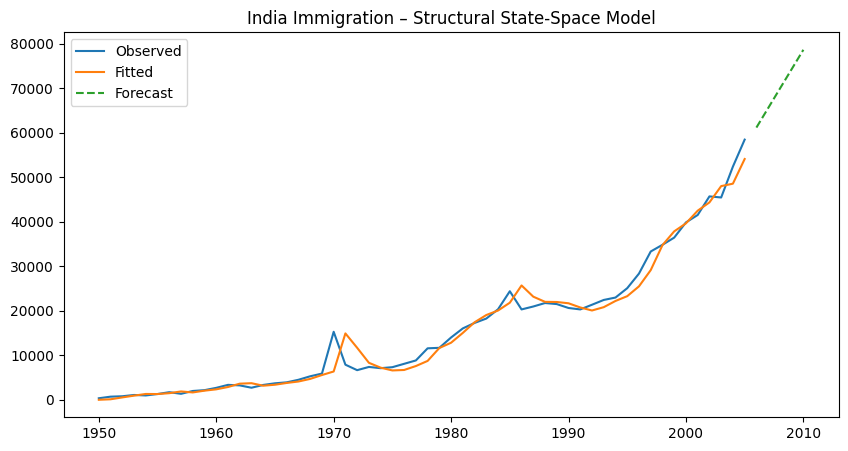

In [117]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm



# 1. Use country-level data only
country_df = df.drop(columns=["total"], errors="ignore")

# 2. log1p transformation for standardization country
country_df_log = np.log1p(country_df)


X = country_df_log.T # Define X as the transpose of country_df_log
X_scaled = StandardScaler().fit_transform(X)

#3.clustering with countries as observations
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

cluster_labels = pd.DataFrame({
    "country": X.index,
    "cluster": clusters
})

# 5. Structural state-space model for India

selected_countries = ['china', 'south_korea', 'united_states', 'india', 'philippines']
selected_df = df[selected_countries]
selected_df.index = pd.PeriodIndex(selected_df.index, freq='Y') # Convert index of selected_df

india_series = selected_df["india"]

model = sm.tsa.UnobservedComponents(
    india_series,
    level="local linear trend"
)
results = model.fit()

# Calculate fitted values
fitted = results.fittedvalues

# 6. Forecast India
forecast_steps = 5
forecast = results.forecast(steps=forecast_steps)

# Convert PeriodIndex to DateTimeIndex for plotting compatibility
india_series_plot = india_series.to_timestamp()
fitted_plot = fitted.to_timestamp()
forecast_plot = forecast.to_timestamp()

# 8. Plot results
plt.figure(figsize=(10, 5))
plt.plot(india_series_plot, label="Observed")
plt.plot(fitted_plot, label="Fitted")
plt.plot(forecast_plot, linestyle="--", label="Forecast")
plt.title("India Immigration – Structural State-Space Model")
plt.legend()
plt.show()

### Model Evaluation-country India

Let's pick one of the countries, for instance, 'India', and perform a detailed model evaluation to understand how well the model fits the data and its statistical properties.

In [118]:
 # Model performance evaluation using (RMSE, MAE) MSE


fitted = results.fittedvalues


mae = mean_absolute_error(india_series, fitted)
mse=mean_squared_error(india_series, fitted)
rmse=np.sqrt(mse)
mae=mean_absolute_error(india_series, fitted)



print("MSE:", mse)



print("RMSE:", rmse)

print("MAE:", mae)


MSE: 5260779.386213346
RMSE: 2293.6388962112906
MAE: 1399.4164702024807


NOTE: the metric MSE is just to ensure that RMSE is the square root of MSE.

# **Forecasting india immigration for year 2025**

In [119]:

last_year = india_series.index.max() # last recorded year in the data set for country india

# substract the year of prediction from the last day of the dataset
steps_to_2025 = 2025 - last_year.year

forecast = results.forecast(steps=steps_to_2025)

# Using teeh period to match the forecast index type
forecast_2025 = forecast.loc[pd.Period(2025, freq='Y')]

print("Forecasted immigration from India in 2025:", forecast_2025)

Forecasted immigration from India in 2025: 144178.17874220642


Additional statistics to understand the RMSE and MAE

In [120]:
# Descriptive statistics
Mean=india_series.mean()
Median=india_series.median()
Standard_Deviation=india_series.std()
print("Mean:", Mean)
print("Median:", Median)
print("Standard Deviation:", Standard_Deviation)

Mean: 15829.589285714286
Median: 11617.0
Standard Deviation: 14749.899161167521


observation: high standard deviation is indicatif of  data being spread over a wider range os value and confirm fluctuations

In [121]:
# total values of india immigration between 1950-2005
india_series.sum()
print("Total immigration from India between 1950 and 2005:", india_series.sum())



Total immigration from India between 1950 and 2005: 886457
